# PA2 — Identidade ao longo do tempo

Notebook do trabalho e da apresentação. As implementações ficam nos `.py`; aqui reunimos experimentos, métricas e visualizações das Partes 0 a 5.

**Roteiro:** ambiente sintético → baseline → detector real → modelo temporal → ablação → memória e falhas → estresse. Para reproduzir, use o ambiente e os dados descritos no README.


In [1]:
from pathlib import Path
import os, sys
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs/parte1.json").exists()), None)
if REPO is None:
    raise RuntimeError("Abra o notebook dentro do repositório.")
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))


# Parte 0 — Ambiente controlado

Antes de usar o MOT17, geramos vídeos de 128×128 pixels com elipses em movimento (`synthetic.py`). Como o gerador conhece cada objeto, ele fornece o **GT**: quadro, ID verdadeiro, caixa `(x, y, largura, altura)` e fração visível. A oclusão é visual: uma elipse na frente cobre os pixels de outra.

De cada GT visível, `corrupt_detections` cria caixas de entrada **sem IDs** e pode descartar detecções, deslocar caixas ou inserir falsos positivos. O `IoUTracker` (`baseline.py`) recebe essas caixas e tenta manter os IDs comparando a sobreposição entre quadros. Assim, podemos testar rastreamento e métricas em situações cuja resposta correta é conhecida.


In [2]:
import io
from contextlib import redirect_stdout
import numpy as np
from IPython.display import display, Image, Markdown
from run_synthetic import run_experiments
from metrics import evaluate

with redirect_stdout(io.StringIO()):
    synthetic_results = run_experiments("outputs/parte0")
easy = synthetic_results["easy"]
assert easy["idf1"] >= 0.98 and easy["id_switches"] == 0
print(f'Piso fácil: IDF1={easy["idf1"]:.2f}, {easy["id_switches"]} switches, '
      f'{easy["predicted_identities"]}/{easy["gt_identities"]} IDs.')

Piso fácil: IDF1=1.00, 0 switches, 5/5 IDs.


### Primeiro, conferir as métricas

Usamos caixas perfeitas em três casos pequenos para separar **localização** de **identidade**. `metrics.py:evaluate` calcula IDF1 (consistência dos IDs), trocas de ID e fragmentações. A tabela abaixo mostra que trocar ou dividir um ID reduz IDF1 mesmo quando todas as caixas continuam corretas.


In [3]:
gt = np.array([[f, i, 30*i, 0, 10, 10] for f in range(1, 5) for i in (1, 2)], float)
swapped = gt.copy()
swapped[swapped[:, 0] >= 3, 1] = 3 - swapped[swapped[:, 0] >= 3, 1]
split = gt.copy()
split[(split[:, 0] >= 3) & (split[:, 1] == 1), 1] = 3
table = "| Caso | IDF1 | Switches | Fragmentações |\n| --- | ---: | ---: | ---: |\n"
for label, predicted, expected in [("Perfeito", gt, (1, 0, 0)),
    ("Dois IDs trocados", swapped, (.5, 2, 0)),
    ("Uma identidade dividida", split, (.75, 1, 0))]:
    m = evaluate(gt, predicted)
    assert np.allclose((m["idf1"], m["id_switches"], m["fragmentations"]), expected)
    table += f'| {label} | {m["idf1"]:.2f} | {m["id_switches"]} | {m["fragmentations"]} |\n'
display(Markdown(table))

| Caso | IDF1 | Switches | Fragmentações |
| --- | ---: | ---: | ---: |
| Perfeito | 1.00 | 0 | 0 |
| Dois IDs trocados | 0.50 | 2 | 0 |
| Uma identidade dividida | 0.75 | 1 | 0 |


### Depois, testar o limite do baseline

Na primeira figura, uma elipse fica totalmente escondida durante **dez quadros** e depois reaparece. O baseline guarda a última caixa por até dois quadros sem detecção; se a ausência ultrapassa esse limite, o retorno pode receber outro ID. No gráfico seguinte variamos **número de objetos**, **velocidade** e **duração da oclusão**, com três seeds por valor (`run_synthetic.py:run_experiments`).


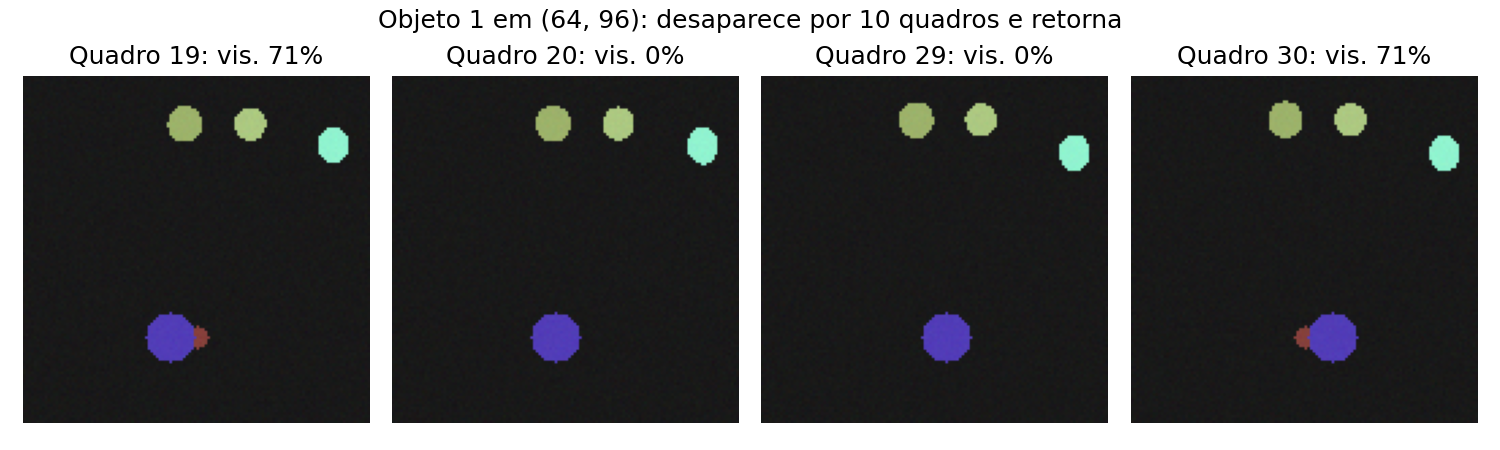

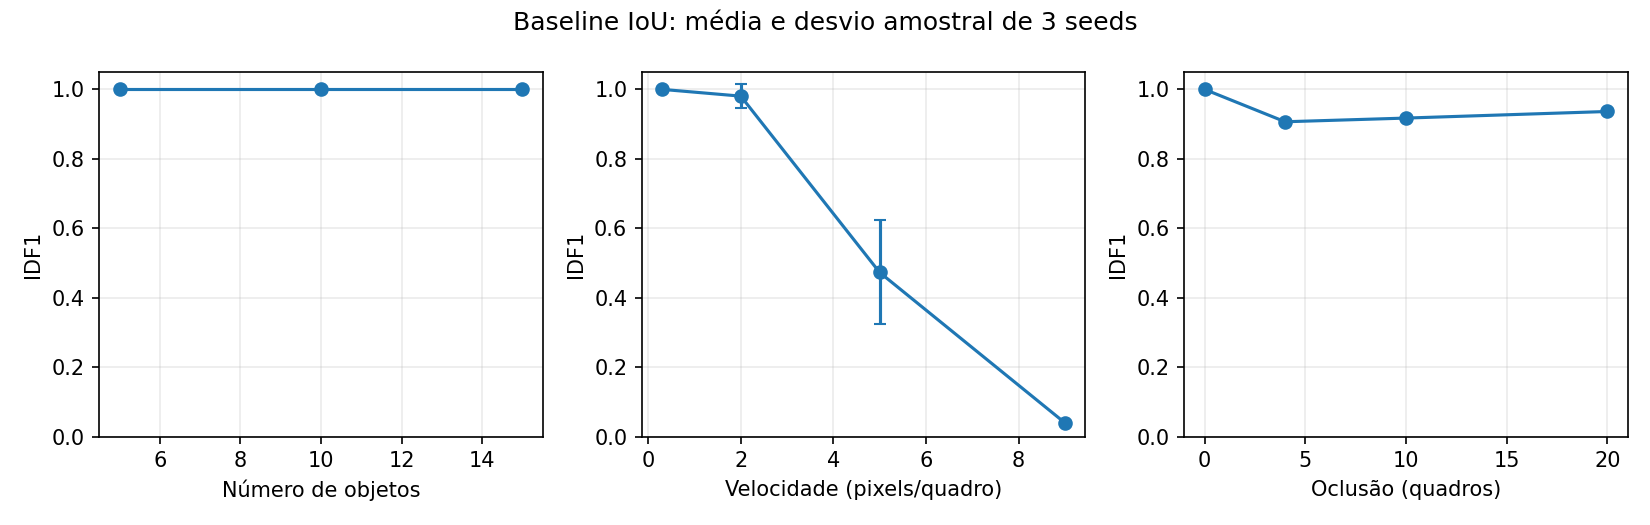

In [4]:
assert len(synthetic_results["fully_hidden_frames"]) == 10
display(Image(filename="outputs/parte0/oclusao.png", width=900))
display(Image(filename="outputs/parte0/baseline_dificuldade.png", width=1000))

**Leitura dos resultados:** no caso fácil, o baseline acerta as cinco identidades (IDF1=1). Com velocidade de 9 pixels/quadro, o IDF1 médio cai para 0,0403: a última caixa observada deixa de se sobrepor à próxima. Oclusões longas também podem criar um ID novo quando o objeto reaparece. Os quadros totalmente invisíveis não entram na avaliação sintética; por isso, uma pequena subida na curva de oclusão **não** significa recuperação da identidade.

Esses testes validam a infraestrutura e mostram a limitação do baseline. A avaliação com pessoas reais começa na Parte 1. Testes completos: `tests/test_core.py` e `tests/test_synthetic.py`.


# Parte 1 — Detecção por quadro e identidade ao longo do tempo

Este notebook usa os módulos do repositório para comparar o baseline IoU nas duas fontes exigidas: FRCNN público e Faster R-CNN ResNet-50 FPN pré-treinado no COCO, classe `person`.

**Objetivo:** medir quando a qualidade espacial da detecção não se traduz em identidade consistente. Não há treinamento nesta parte. As caixas públicas ficam congeladas para as Partes 2–5.

Instale `requirements-detector.txt` no Python usado pelo kernel. Em máquina com RTX 4050, instale o PyTorch com suporte a CUDA conforme o [seletor oficial](https://pytorch.org/get-started/locally/). Os mesmos módulos funcionam em CPU, GPU e Colab; no Colab basta clonar o repositório e executá-lo a partir de sua raiz.

Neste notebook unificado, benchmark e inferência ficam desligados para reutilizar os caches. Para apenas avaliar caches, defina `PA2_RUN_BENCHMARK` e `PA2_RUN_DETECT` como `"0"` nessa célula. Download continua opcional. A avaliação final só fica completa depois que ambas as fontes tiverem os três vídeos inteiros.

In [11]:
# Habilite somente para baixar dados ou refazer benchmark/inferencia.
os.environ["PA2_RUN_DETECT"] = "0"
os.environ["PA2_RUN_BENCHMARK"] = "0"

In [12]:
from pathlib import Path
import os, sys, json, csv
from IPython.display import display, Image, Markdown

# Funciona abrindo o notebook da raiz ou de uma pasta interna do repositório.
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs/parte1.json").exists()), None)
if REPO is None:
    raise RuntimeError("Abra este notebook dentro do repositório clonado.")
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from mot_data import load_config, Sequence, valid_gt
from parte1 import evaluate_all
CONFIG = load_config(os.environ.get("PA2_CONFIG", "configs/parte1.json"))
DATA = Path(os.environ.get("PA2_DATA_ROOT", "data/MOT17"))
OUTPUT = Path(os.environ.get("PA2_OUTPUT", "outputs/parte1"))
CACHE = Path(os.environ.get("PA2_CACHE", "data/detections/torchvision"))
DEVICE = "auto"
RUN_DOWNLOAD = os.environ.get("PA2_RUN_DOWNLOAD", "0") == "1"
RUN_DETECT = os.environ.get("PA2_RUN_DETECT", "0") == "1"
RUN_BENCHMARK = os.environ.get("PA2_RUN_BENCHMARK", "0") == "1"
RUN_VISUALS = os.environ.get("PA2_RUN_VISUALS", "1") == "1"
print("Treino:", CONFIG["split"]["train"])
print("Validação:", CONFIG["split"]["validation"])
print("Fonte padrão:", CONFIG["public_detector"])
print("Inferência pesada habilitada:", RUN_DETECT)

Treino: ['MOT17-04', 'MOT17-05', 'MOT17-10', 'MOT17-11']
Validação: ['MOT17-02', 'MOT17-09', 'MOT17-13']
Fonte padrão: FRCNN
Inferência pesada habilitada: False


## 1. Dados e split

O split é por vídeo físico: treino em 04, 05, 10 e 11; validação em 02, 09 e 13. Nenhuma cópia DPM/FRCNN/SDP cruza o split. A validação cobre densidades e pontos de vista distintos; é um conjunto de validação, não um teste independente para seleção contínua de modelos.

O pacote de labels basta para o baseline público. As imagens são necessárias ao detector torchvision e às figuras. O download seletivo usa HTTP Range e extrai somente FRCNN, evitando cópias duplicadas. Dados não são enviados ao Git.

MOT usa posições 1-based. `mot_data.py` converte para `xywh` 0-based internamente e preserva classe, marca de avaliação e visibilidade. Frames e IDs continuam 1-based.

In [13]:
if RUN_DOWNLOAD:
    import subprocess
    subprocess.run([sys.executable, "download_mot17.py", "--root", str(DATA)], check=True)
    subprocess.run([sys.executable, "download_mot17.py", "--package", "frames", "--root", str(DATA),
                    "--sequences", *CONFIG["split"]["validation"]], check=True)

SEQUENCES = {name: Sequence.load(DATA, name, CONFIG["public_detector"])
             for name in CONFIG["split"]["train"] + CONFIG["split"]["validation"]}
for name, seq in SEQUENCES.items():
    gt = valid_gt(seq.ground_truth())
    print(f"{name}: {seq.length} quadros, {seq.width}x{seq.height}, "
          f"{seq.fps:g} FPS, densidade={len(gt)/seq.length:.1f}")

MOT17-04: 1050 quadros, 1920x1080, 30 FPS, densidade=45.3
MOT17-05: 837 quadros, 640x480, 14 FPS, densidade=8.3
MOT17-10: 654 quadros, 1920x1080, 30 FPS, densidade=19.6
MOT17-11: 900 quadros, 1920x1080, 30 FPS, densidade=10.5
MOT17-02: 600 quadros, 1920x1080, 30 FPS, densidade=31.0
MOT17-09: 525 quadros, 1920x1080, 30 FPS, densidade=10.1


MOT17-13: 750 quadros, 1920x1080, 25 FPS, densidade=15.5


## 2. Inspeção das caixas

GT e detecções são apresentados separadamente para evitar confundir resposta correta com entrada do rastreador. As detecções **não têm identidade**. A visibilidade serve para análise; não é disponibilizada ao baseline.

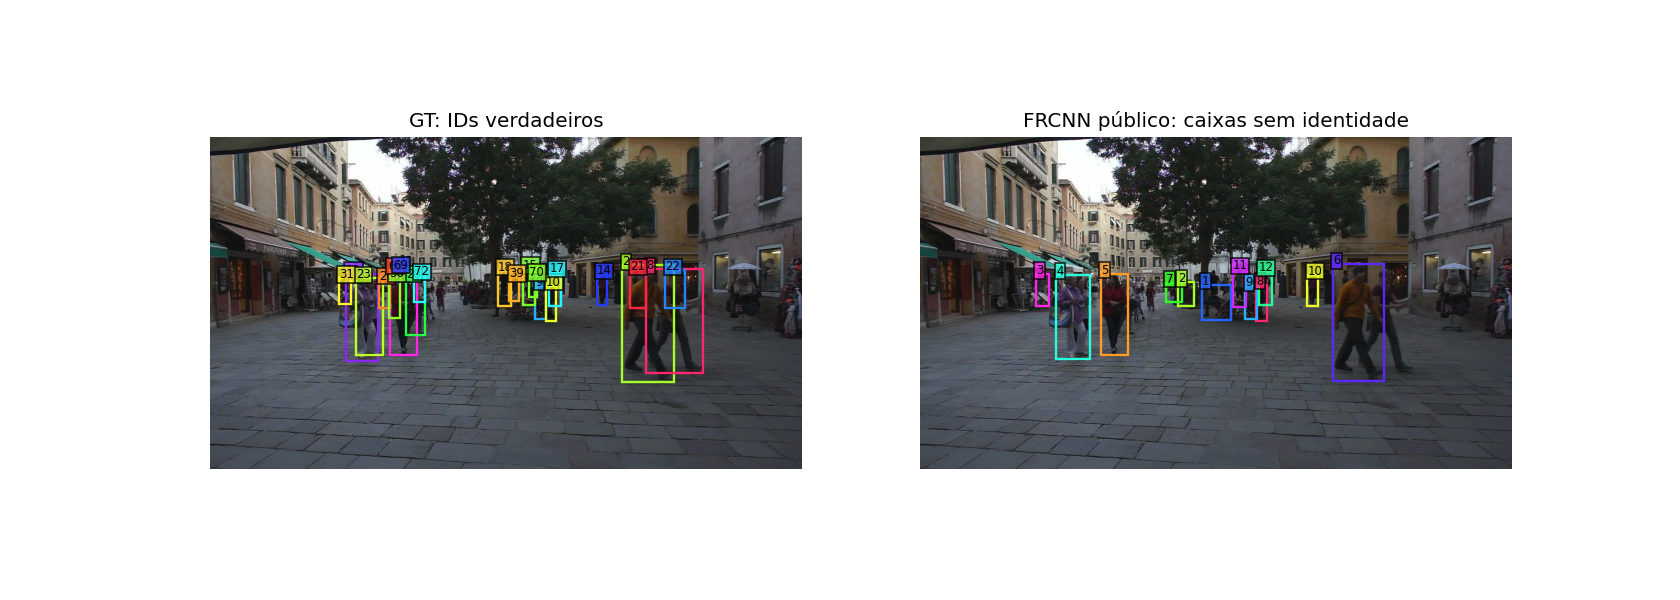

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image as PILImage
from visualization import draw_boxes

EXAMPLE = CONFIG["split"]["validation"][0]
seq = SEQUENCES[EXAMPLE]
if seq.image_path(1).exists():
    with PILImage.open(seq.image_path(1)) as image:
        pixels = np.asarray(image.convert("RGB"))
    gt = valid_gt(seq.ground_truth())
    gt = gt[gt[:, 0] == 1]
    det = seq.public_detections()
    det = det[(det[:, 0] == 1) & (det[:, 5] >= CONFIG["score_threshold"])]
    # IDs temporários servem apenas para desenhar caixas, não são IDs rastreados.
    boxes_for_display = np.column_stack([det[:, 0], np.arange(1, len(det)+1), det[:, 1:5]])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, values, title in zip(axes, [gt, boxes_for_display], ["GT: IDs verdadeiros", "FRCNN público: caixas sem identidade"]):
        ax.imshow(pixels)
        draw_boxes(ax, values)
        ax.set_title(title)
        ax.axis("off")
    from io import BytesIO
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=120)
    display(Image(data=buffer.getvalue()))
    plt.close(fig)
else:
    display(Markdown("Imagens ainda ausentes; a avaliação pública abaixo funciona só com labels."))

## 3. Baseline e regras da avaliação

`baseline.py`, classe `IoUTracker`: Hungarian sobre IoU com limiar 0,3, nascimento imediato e tolerância de dois quadros intermediários sem observação. Usa a última caixa observada, sem movimento aprendido. Tracks ocultas não emitem caixas.

`metrics.py`: IDF1 com atribuição global um-para-um, switches comparados ao último ID associado, fragmentação como interrupção e retomada nas observações GT, erro absoluto de IDs únicos. IoU de avaliação: 0,5.

`mot_data.py`: pedestres com marca válida; visibilidade baixa ou zero não é excluída. Predições associadas a GT ignorado são desconsideradas **depois** da inferência, com prioridade a pedestres válidos. É nosso protocolo `pa2-pedestrians-v1`, não o avaliador oficial MOTChallenge.

`detection_metrics.py`: AP50 e mAP@0,50:0,95 com 101 pontos de recall. Matching espacial independente por imagem; agregação por sequência. A avaliação espacial não usa identidades. AP e tracking usam o mesmo corte de confiança 0,5. O AP é, portanto, limitado às detecções acima desse corte.

In [15]:
# Fonte pública: avaliação completa das sete sequências, reutilizável pela Pessoa 2.
public_results = evaluate_all(DATA, CONFIG, OUTPUT, sources=("public",))
columns = ["sequence", "split", "ap50", "map_50_95", "idf1", "id_switches", "fragmentations", "predicted_identities", "gt_identities"]
table = "| " + " | ".join(columns) + " |\n| " + " | ".join(["---"] * len(columns)) + " |\n"
for row in public_results:
    table += "| " + " | ".join(f"{row[c]:.4f}" if isinstance(row[c], float) else str(row[c]) for c in columns) + " |\n"
display(Markdown(table))

MOT17-04 [public] IDF1=0.5716 AP50=0.5446 mAP=0.4334 IDs=149/83


MOT17-05 [public] IDF1=0.5461 AP50=0.5045 mAP=0.3235 IDs=160/133


MOT17-10 [public] IDF1=0.4448 AP50=0.5810 mAP=0.4029 IDs=329/57


MOT17-11 [public] IDF1=0.5525 AP50=0.5840 mAP=0.4906 IDs=115/75


MOT17-02 [public] IDF1=0.3632 AP50=0.3363 mAP=0.2659 IDs=135/62


MOT17-09 [public] IDF1=0.5515 AP50=0.5544 mAP=0.4638 IDs=50/26


MOT17-13 [public] IDF1=0.4640 AP50=0.5607 mAP=0.3853 IDs=518/110


| sequence | split | ap50 | map_50_95 | idf1 | id_switches | fragmentations | predicted_identities | gt_identities |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| MOT17-04 | train | 0.5446 | 0.4334 | 0.5716 | 86 | 109 | 149 | 83 |
| MOT17-05 | train | 0.5045 | 0.3235 | 0.5461 | 86 | 85 | 160 | 133 |
| MOT17-10 | train | 0.5810 | 0.4029 | 0.4448 | 352 | 361 | 329 | 57 |
| MOT17-11 | train | 0.5840 | 0.4906 | 0.5525 | 60 | 63 | 115 | 75 |
| MOT17-02 | validation | 0.3363 | 0.2659 | 0.3632 | 87 | 135 | 135 | 62 |
| MOT17-09 | validation | 0.5544 | 0.4638 | 0.5515 | 36 | 42 | 50 | 26 |
| MOT17-13 | validation | 0.5607 | 0.3853 | 0.4640 | 591 | 380 | 518 | 110 |


## 4. Inferência torchvision e custo

Faster R-CNN ResNet-50 FPN, pesos COCO_V1, sem fine-tuning. O NMS interno do RPN e das caixas finais é substituído pelo nosso NMS em um escopo temporário, restaurado mesmo após erro.

Para executar a comparação, altere `RUN_BENCHMARK` e `RUN_DETECT` para `True` na primeira célula. `DEVICE="auto"` seleciona CUDA quando disponível. O benchmark usa cinco warmups e 30 quadros; mede tempo, memória e projeta custo para 1.875 quadros.

Cache: uma detecção por arquivo/quadro, incluindo quadros vazios; manifesto com hashes das imagens, detecções, código e configuração. A execução pode ser retomada. Mudanças incompatíveis geram erro, nunca reutilização silenciosa.

In [16]:
if RUN_BENCHMARK or RUN_DETECT:
    from detector import build_detector, benchmark, extract_detections
    model, transform, device, versions = build_detector(CONFIG, DEVICE)
    OUTPUT.mkdir(parents=True, exist_ok=True)
    if RUN_BENCHMARK:
        print(benchmark(SEQUENCES[EXAMPLE], model, transform, device, OUTPUT / "benchmark.json"))
    if RUN_DETECT:
        for name in CONFIG["split"]["validation"]:
            extract_detections(SEQUENCES[name], CONFIG, CACHE, model, transform, device, versions)
    del model
else:
    display(Markdown("Inferência pesada desligada. Habilite-a na primeira célula ou execute `python parte1.py detect`."))

Inferência pesada desligada. Habilite-a na primeira célula ou execute `python parte1.py detect`.

## 5. Comparação e gráfico obrigatório

O notebook tenta carregar a fonte torchvision nas três sequências **inteiras**. Cache ausente, parcial ou incompatível impede afirmar que a Parte 1 está completa.

Painel superior: mAP e IDF1. Painel inferior: razão de IDs e switches por identidade verdadeira. A ordem vem da densidade GT, não dos resultados. As escalas da razão de IDs e dos switches são indicadas nos dois eixos do painel inferior.

MOT17-04 [public] IDF1=0.5716 AP50=0.5446 mAP=0.4334 IDs=149/83


MOT17-05 [public] IDF1=0.5461 AP50=0.5045 mAP=0.3235 IDs=160/133


MOT17-10 [public] IDF1=0.4448 AP50=0.5810 mAP=0.4029 IDs=329/57


MOT17-11 [public] IDF1=0.5525 AP50=0.5840 mAP=0.4906 IDs=115/75


MOT17-02 [public] IDF1=0.3632 AP50=0.3363 mAP=0.2659 IDs=135/62


MOT17-02 [torchvision] IDF1=0.3078 AP50=0.4166 mAP=0.2338 IDs=707/62


MOT17-09 [public] IDF1=0.5515 AP50=0.5544 mAP=0.4638 IDs=50/26


MOT17-09 [torchvision] IDF1=0.4512 AP50=0.7159 mAP=0.4320 IDs=326/26


MOT17-13 [public] IDF1=0.4640 AP50=0.5607 mAP=0.3853 IDs=518/110


MOT17-13 [torchvision] IDF1=0.3307 AP50=0.5432 mAP=0.2628 IDs=1248/110


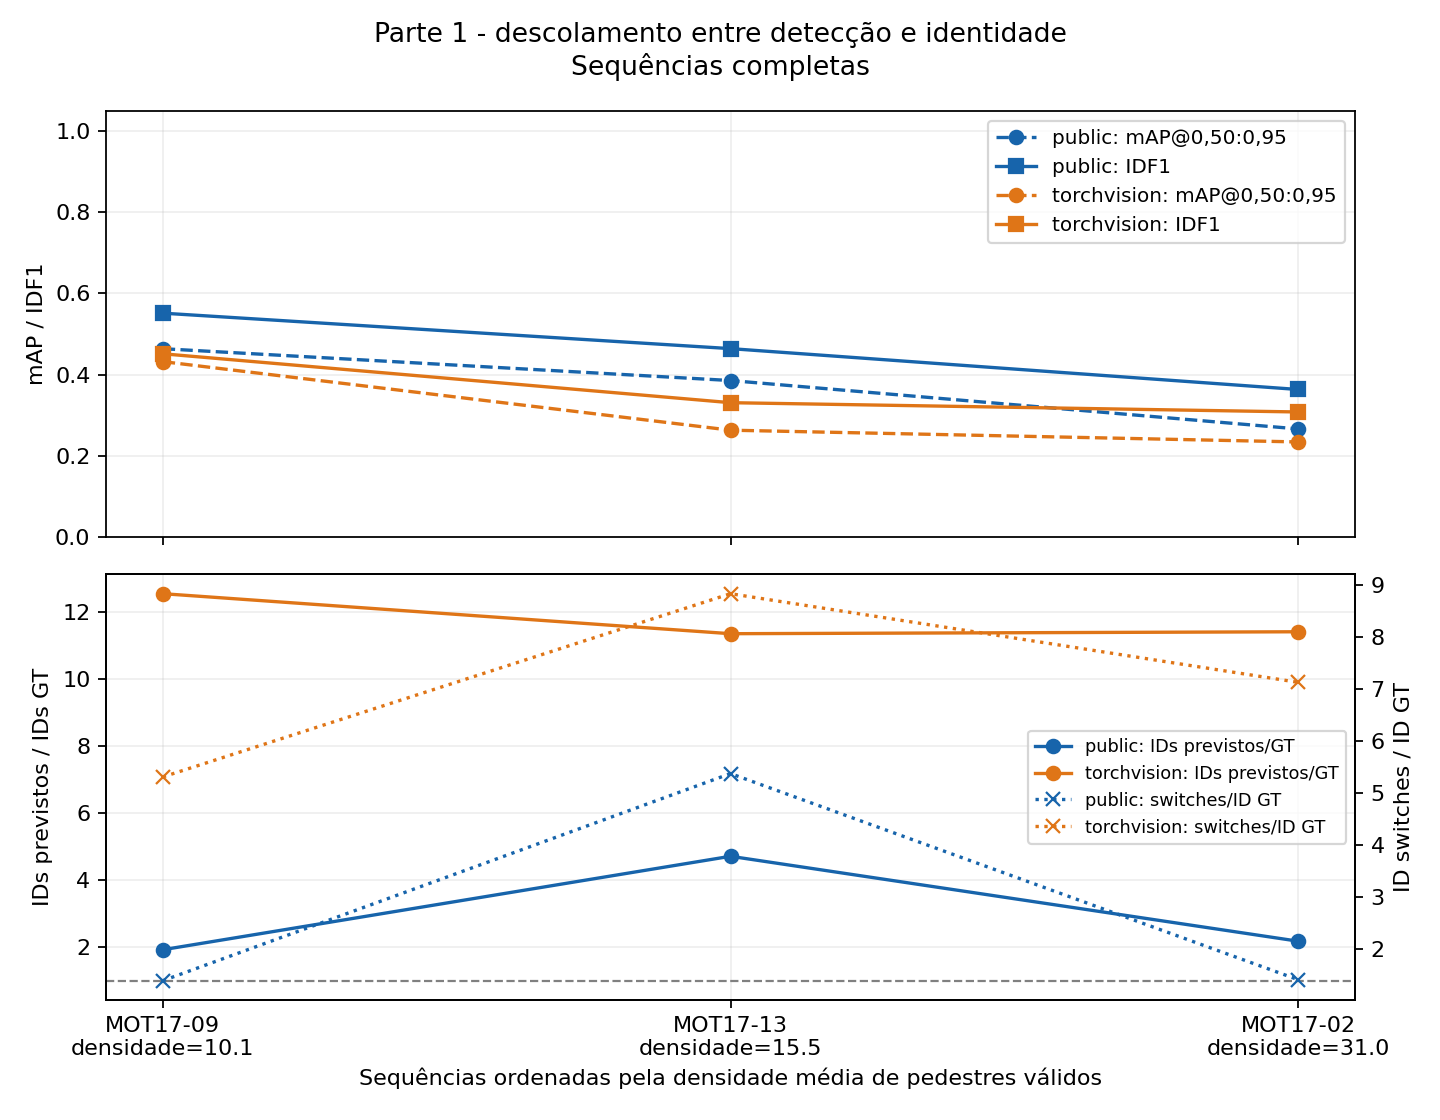

Parte 1 completa: True
Métricas salvas: metrics.csv


In [17]:
from detector import load_cached_detections
cache_ready = True
try:
    for name in CONFIG["split"]["validation"]:
        load_cached_detections(SEQUENCES[name], CONFIG, CACHE)
except (FileNotFoundError, ValueError) as error:
    cache_ready = False
    display(Markdown(f"**Comparação torchvision pendente:** {error}"))

if cache_ready:
    results = evaluate_all(DATA, CONFIG, OUTPUT, sources=("public", "torchvision"), cache_dir=CACHE)
else:
    results = public_results
display(Image(filename=str(OUTPUT / "descolamento.png")))
payload = json.loads((OUTPUT / "results.json").read_text(encoding="utf-8"))
print("Parte 1 completa:", payload["complete_part1"])
print("Métricas salvas:", (OUTPUT / "metrics.csv").name)

## 6. Exemplos visuais e interpretação

As figuras mostram GT e baseline em linhas separadas, com cores determinísticas por identidade. Um ID previsto numericamente diferente do GT não significa erro; o que importa é sua consistência temporal. Os exemplos são escolhidos automaticamente por eventos observados, sem inventar falhas.

Investigue: a maior densidade sempre piorou IDF1? Movimento de câmera parece explicar exceções? Muitas identidades novas surgem mesmo quando o detector encontra caixas válidas? mAP e IDF1 medem propriedades diferentes e não precisam ter valores ou ordenação iguais.

### Leitura dos resultados completos

O público supera o torchvision em IDF1 nas três sequências: 0,3632 vs. 0,3078 (02), 0,5515 vs. 0,4512 (09) e 0,4640 vs. 0,3307 (13), na execução local com caches CPU.

Na MOT17-09, AP50 sobe de 0,5544 para 0,7160, mas IDF1 cai de 0,5515 para 0,4512. Para 26 pessoas, o baseline cria 50 IDs com o público e 326 com torchvision. Melhor detecção no limiar IoU 0,5 não garante continuidade temporal. O mAP cai nas três sequências, portanto o ganho de AP50 em 02 e 09 não significa melhoria em todos os limiares.

A MOT17-13 tem menor densidade que a 02, mas gera mais identidades excedentes nas duas fontes. Movimento de câmera, oclusão e oscilação das caixas são hipóteses; as métricas agregadas não demonstram causalidade. Sem previsão de movimento, o baseline pode perder associações quando a última caixa deixa de ter IoU suficiente.

Mantemos o FRCNN público já fixado no contrato para comparar o modelo temporal usando as mesmas entradas e métricas. O benchmark CUDA registrado no notebook individual da Parte 1 projeta 11,88 minutos a partir de 30 quadros medidos; não mede o tempo total da execução completa.


{'mantido': {'gt_id': 2, 'before': 1, 'after': 2, 'prediction_before': 6, 'prediction_after': 6}, 'retorno_id_novo': {'gt_id': 8, 'before': 16, 'after': 30, 'prediction_before': 13, 'prediction_after': 16}, 'troca': {'gt_id': 27, 'before': 85, 'after': 86, 'prediction_before': 20, 'prediction_after': 21}}


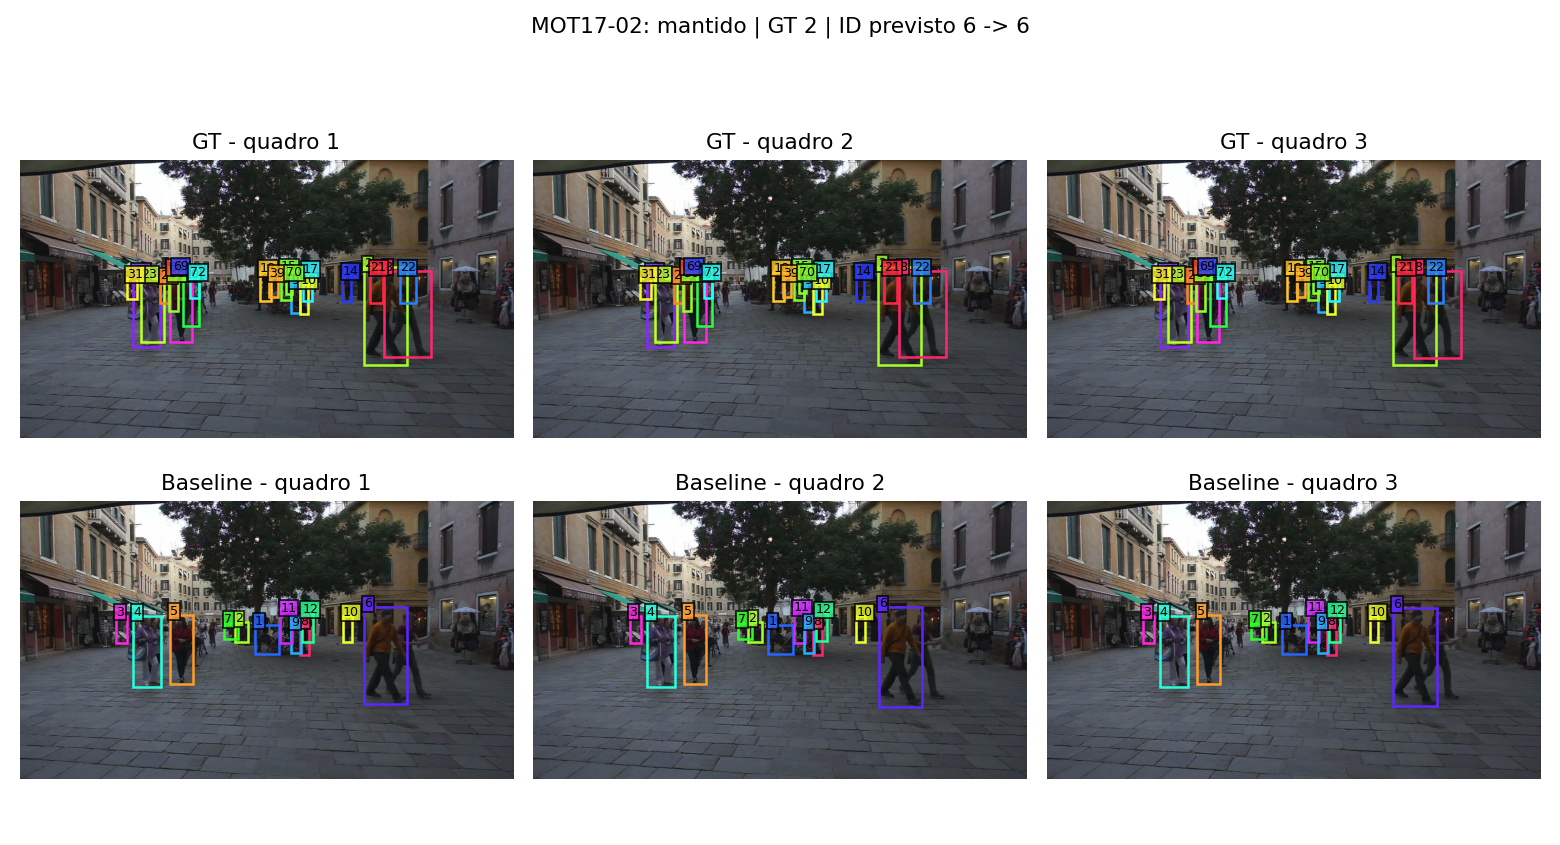

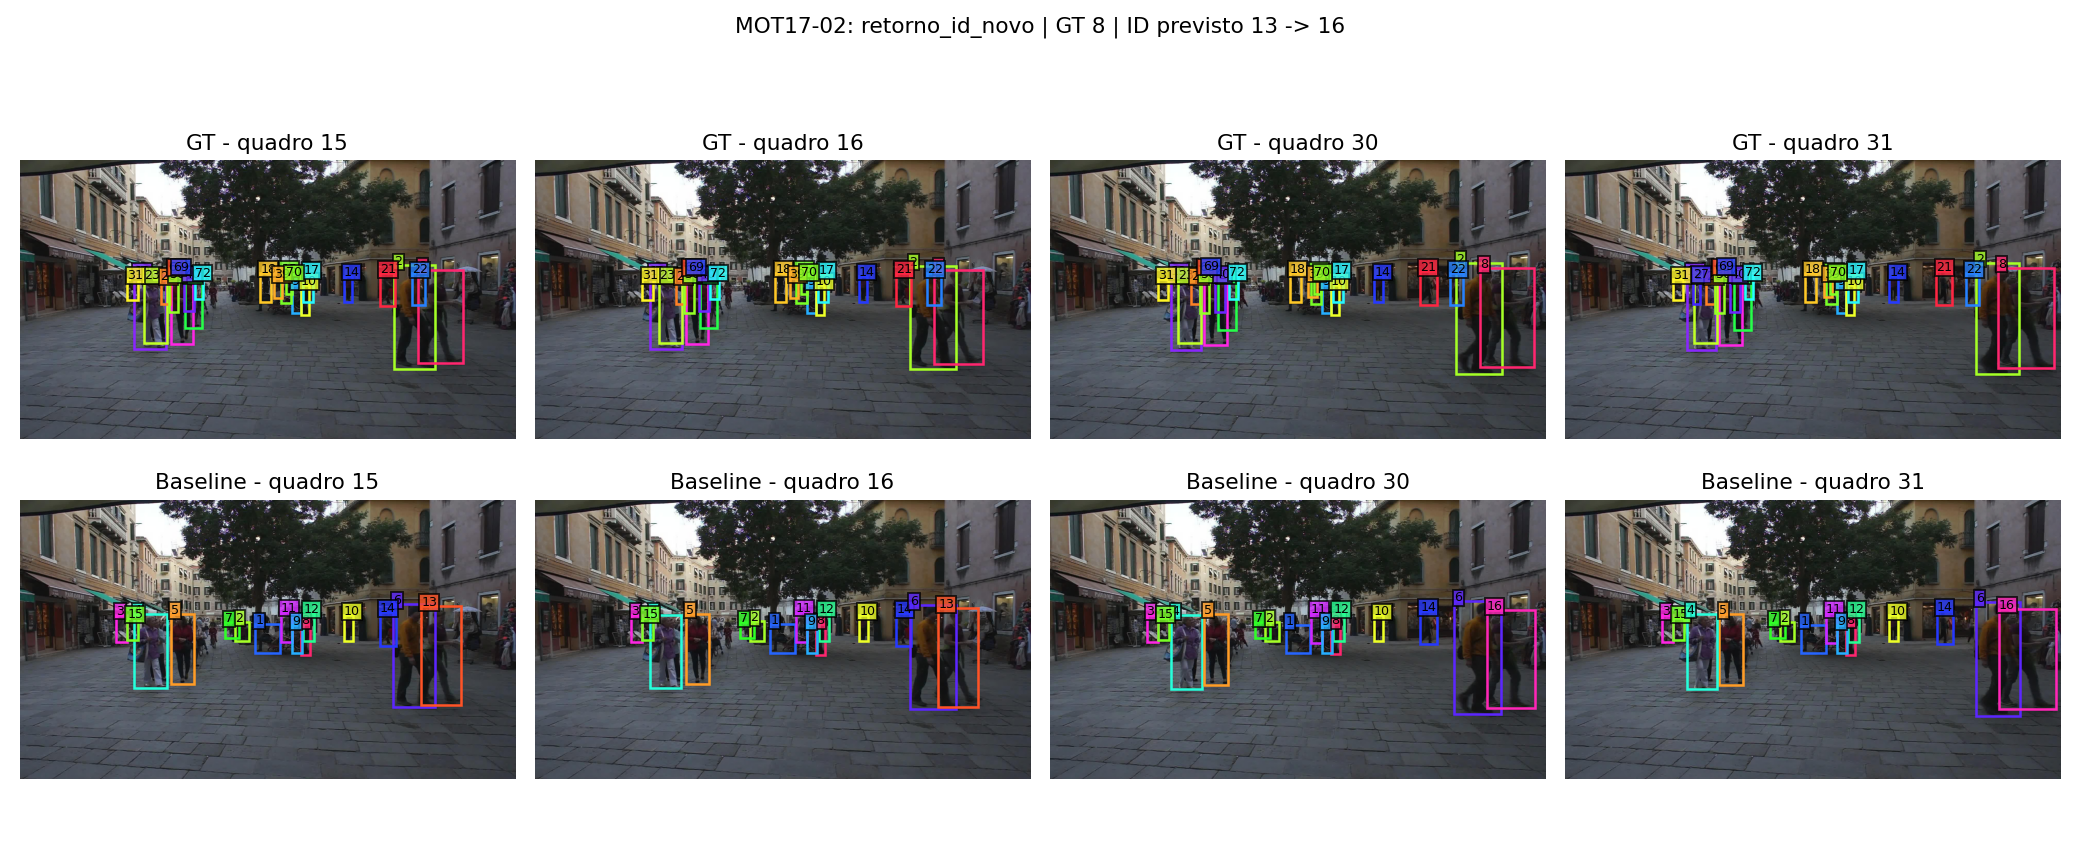

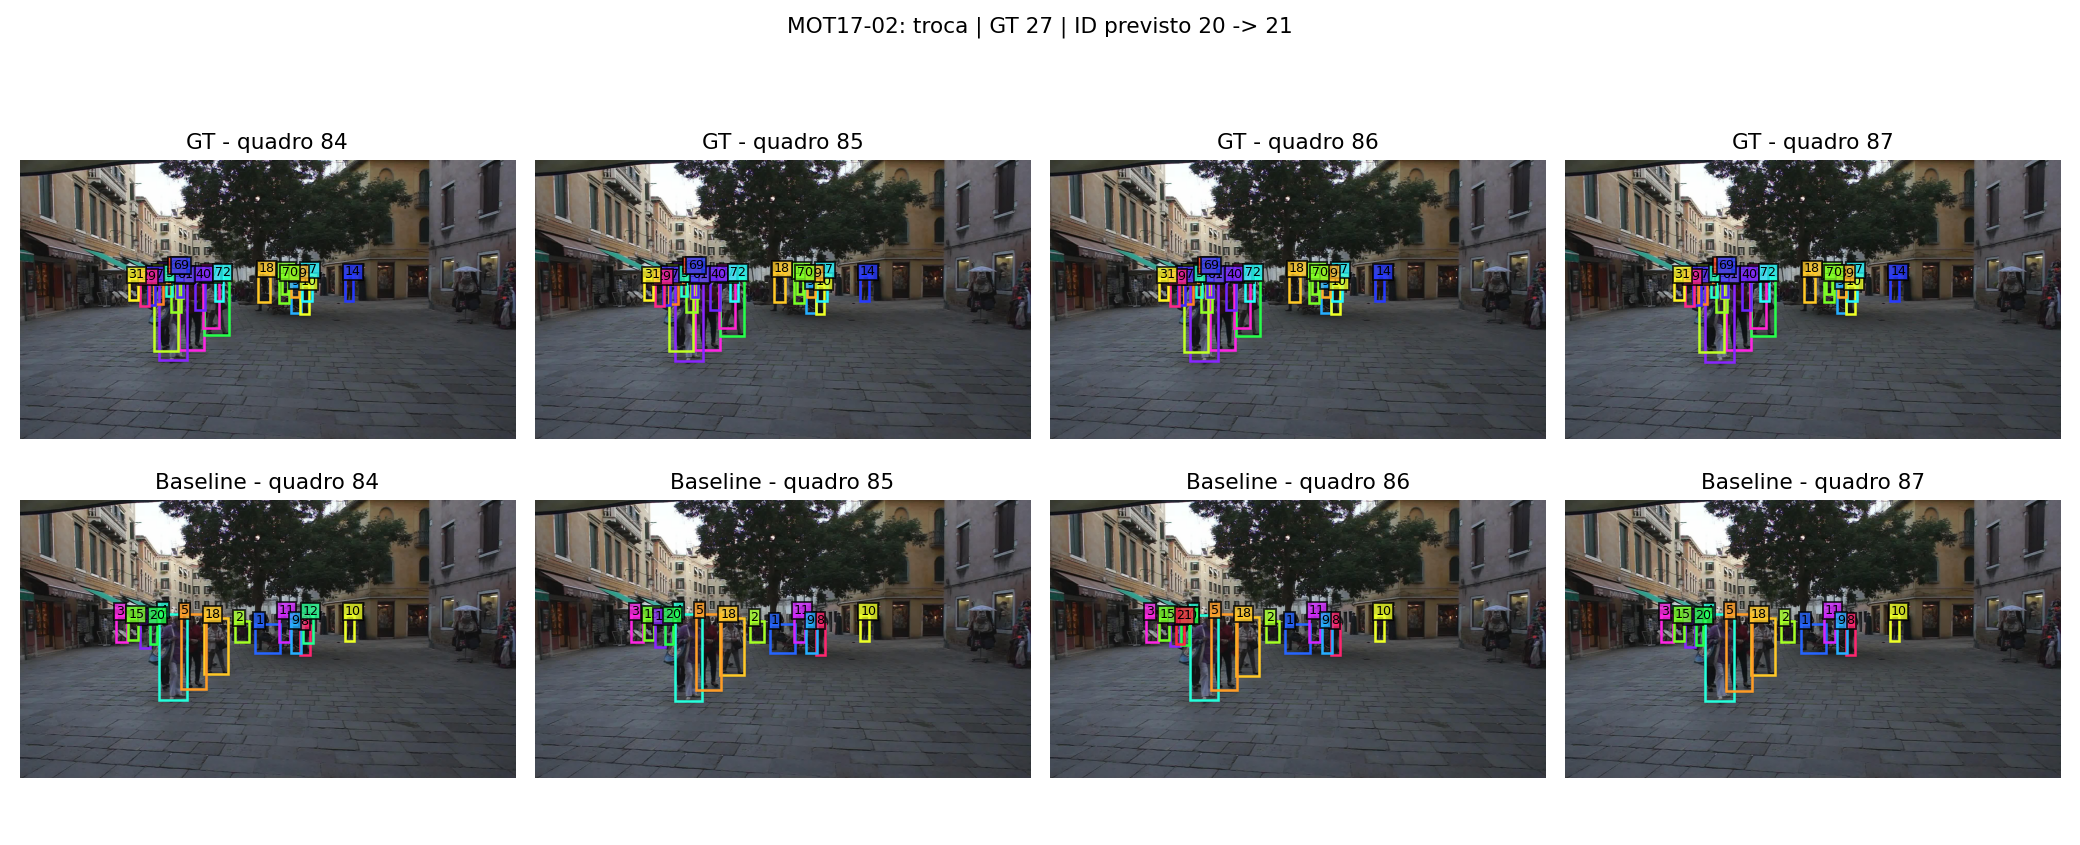

In [18]:
from visualization import example_strips
if RUN_VISUALS and all(SEQUENCES[EXAMPLE].image_path(f).exists() for f in range(1, SEQUENCES[EXAMPLE].length+1)):
    events = example_strips(SEQUENCES[EXAMPLE], OUTPUT / "predictions/public" / f"{EXAMPLE}.txt", OUTPUT / "examples", CONFIG)
    print(events)
    for path in sorted((OUTPUT / "examples").glob(f"{EXAMPLE}-*.png")):
        display(Image(filename=str(path)))
else:
    display(Markdown("Exemplos visuais desligados ou imagens incompletas."))

# Parte 2 — Modelo temporal

GRU prevê a próxima caixa e a usa na associação. Comparação com o baseline no mesmo FRCNN público e nas mesmas sequências MOT17. O treino e o experimento sintético estão em `trabalhop2.ipynb`.

In [ ]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display

temporal_path = Path("outputs/temporal/results.json")
if not temporal_path.exists():
    from run_temporal import compare
    compare(device="auto")
temporal_results = json.loads(temporal_path.read_text(encoding="utf-8"))
display(pd.DataFrame([{"sequence": row["sequence"], "model": label, **row[label]}
                      for row in temporal_results["results"] for label in ("baseline", "temporal")])[
    ["sequence", "model", "idf1", "id_switches", "predicted_identities"]])


# Parte 3 — Ablação

O experimento completo compara RNN, GRU e LSTM, quatro comprimentos de janela e três seeds em `trabalhop2.ipynb`.

In [ ]:
# Tabela da ablação executada no notebook de experimentos.
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, HTML
ablation_csv = Path("outputs/ablation/idf1.csv")
if ablation_csv.exists():
    display(pd.read_csv(ablation_csv, index_col=0))
else:
    source_nb = json.loads(Path("partes2-3-4.ipynb").read_text(encoding="utf-8"))
    outputs = source_nb["cells"][7]["outputs"]
    html = [o["data"]["text/html"] for o in outputs if "text/html" in o.get("data", {})]
    if html:
        display(HTML("".join(html[-1])))
        print("Tabela preservada do notebook original; execute a Parte 3 de trabalhop2.ipynb para recalcular.")
    else:
        print("Execute a Parte 3 de trabalhop2.ipynb para gerar a tabela.")


# Parte 4 — Falhas e memória

As faixas mostram GT, ID previsto e caixa futura da GRU. O gráfico de oclusão usa somente episódios com ID associado antes do desaparecimento para calcular sobrevivência.

In [ ]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

analysis_path = Path("outputs/temporal_analysis")
if not (analysis_path / "results.json").exists():
    from temporal_analysis import analyze
    analyze(device="auto")
analysis_results = json.loads((analysis_path / "results.json").read_text(encoding="utf-8"))
display(pd.DataFrame(analysis_results["correction_max_age_2_to_8"])[
    ["sequence", "max_age", "idf1", "id_switches"]])
for name in ("gradientes.png", "sobrevivencia.png", *
             [f"falha-{e['sequence']}.png" for e in analysis_results["failure_gallery"]]):
    display(Image(filename=str(analysis_path / name), width=780))


# Parte 5 — Qualidade do detector

Três intensidades, sem retreino, nas mesmas sequências e detecções públicas congeladas. O gerador não usa GT. A comparação com o modelo temporal final é obrigatória; o baseline sozinho não finaliza esta parte.

Parâmetros e comandos estão no README e em `configs/parte5.json`. As intensidades combinam descarte, ruído e FP, portanto não isolam cada causa.

In [ ]:
from temporal_stress import run as run_stress
from pathlib import Path
import json
from IPython.display import display, Image

OUTPUT = Path("outputs/parte5")
if not (OUTPUT / "results.json").exists() or not json.loads(
        (OUTPUT / "results.json").read_text(encoding="utf-8")).get("complete_part5"):
    run_stress(device="auto")
results = json.loads((OUTPUT / "results.json").read_text(encoding="utf-8"))
print("Parte 5 completa:", results["complete_part5"])
print(json.dumps(results["stress"], indent=2))


baseline original mAP= 0.3717 IDF1= 0.4595
baseline leve mAP= 0.2764 IDF1= 0.3784
baseline medio mAP= 0.1165 IDF1= 0.1845
baseline forte mAP= 0.0256 IDF1= 0.053


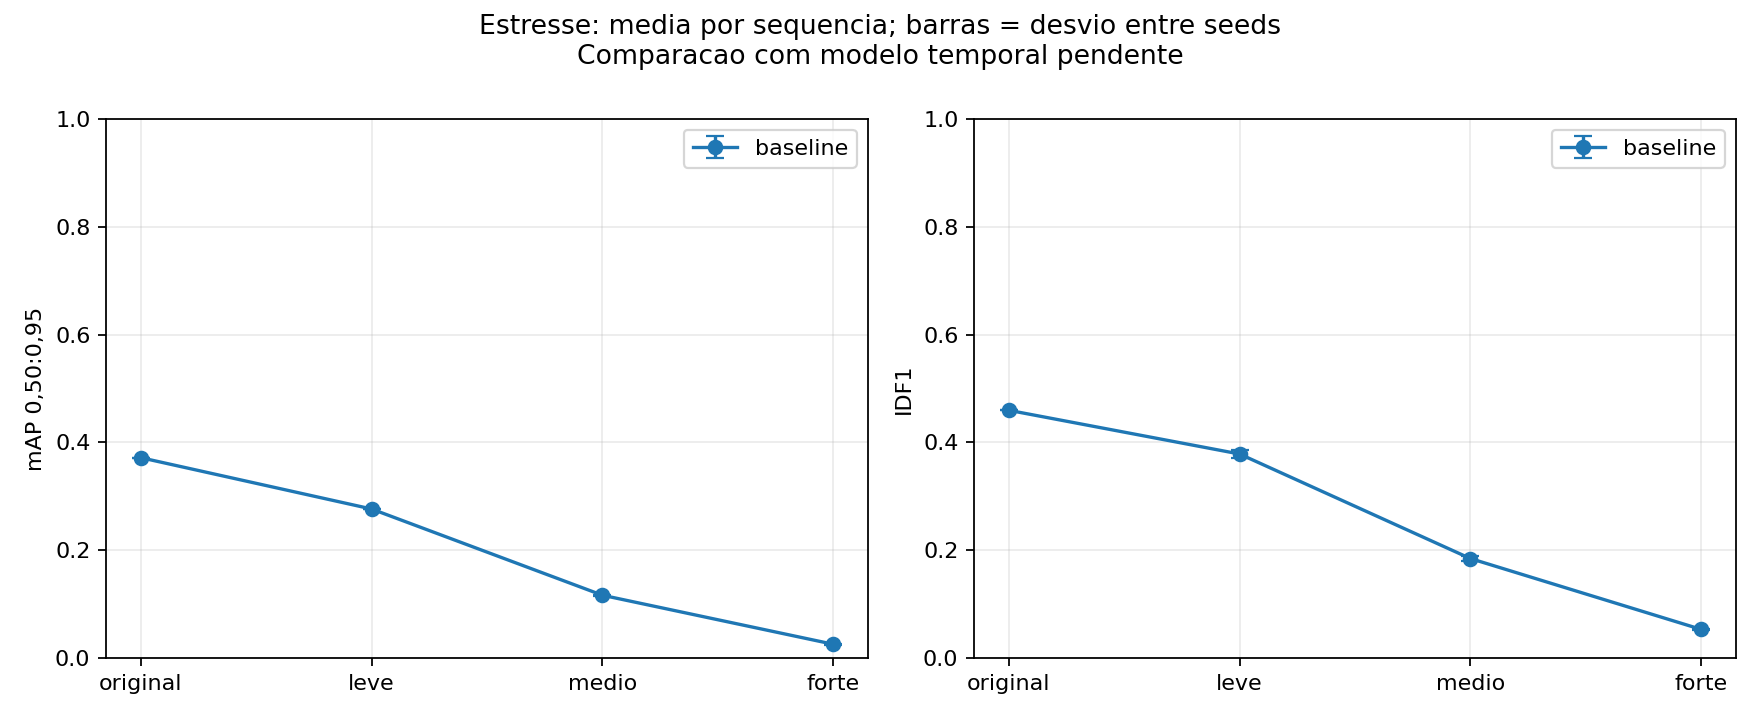

In [20]:
rows = results["results"]
for model in sorted({r["model"] for r in rows}):
    for level in ["original", *results["stress"]["levels"]]:
        selected = [r for r in rows if r["model"] == model and r["level"] == level]
        print(model, level, "mAP=", round(sum(r["map_50_95"] for r in selected)/len(selected), 4),
              "IDF1=", round(sum(r["idf1"] for r in selected)/len(selected), 4))
display(Image(filename=str(OUTPUT / "estresse.png")))

## Interpretação

mAP avalia as entradas espaciais e é compartilhado pelos dois modelos; IDF1 avalia suas identidades. Compare a queda de IDF1 em relação ao controle original de cada modelo para discutir se a recorrência absorve ou amplifica a degradação. Considere também switches, fragmentações e contagem na tabela CSV.

Barras: desvio padrão entre seeds das médias por sequência. Duração completa preservada; quadros sem detecções continuam sendo processados. Sem resultados do checkpoint final, nenhuma conclusão sobre robustez temporal está estabelecida.

### Baseline executado

Médias dos três vídeos e três seeds: original mAP=0,3717 / IDF1=0,4595; leve 0,2764 / 0,3784; médio 0,1165 / 0,1845; forte 0,0256 / 0,0530. A intensidade forte reduz o IDF1 em aproximadamente 88,5% em relação ao controle. Esses valores estabelecem a referência do baseline; falta medir a recorrência final nas mesmas entradas.
